# предсказание выживаемости пассажиров Титаника

### библиотеки и просмотр данных

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_initial = pd.read_csv("D:\Dataset\Titanic-Dataset.csv")
df = df_initial.copy()

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### переимнновываем названия колонок


In [2]:
df = df.rename(columns = {'PassengerId':'id_пассажира',
                          'Survived':'Выжил',
                          'Pclass':'класс',
                          'Name':'имя',
                          'Sex':'пол',
                          'Age':'возраст',
                          'SibSp':'количество_братьев_супругов',
                          'Parch':'родители_и_дети',
                          'Ticket':'Билет',
                          'Fare':'цена',
                          'Cabin':'Каюта',
                          'Embarked':'порт'})


# EDA

In [3]:
print(f'NaN в df: \n{ df.isnull().sum()}') # вывод колва нулей по столбцам


NaN в df: 
id_пассажира                     0
Выжил                            0
класс                            0
имя                              0
пол                              0
возраст                        177
количество_братьев_супругов      0
родители_и_дети                  0
Билет                            0
цена                             0
Каюта                          687
порт                             2
dtype: int64


### строим 2 графика, показывающих вероятность выживания в зависимости от наличия или отсутствия записи "каюта"

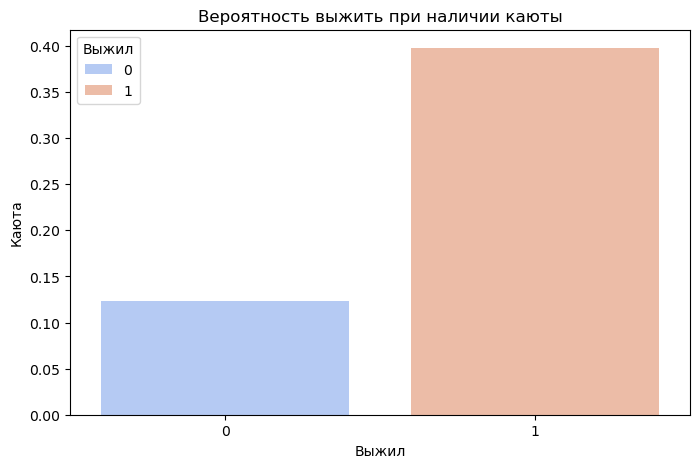

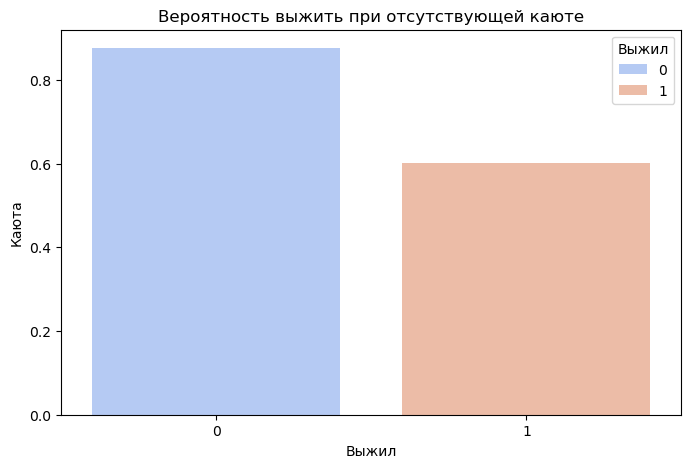

In [4]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x=df['Выжил'], y=df['Каюта'].notnull(), hue='Выжил', errorbar=None, palette='coolwarm')
plt.title('Вероятность выжить при наличии каюты')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x=df['Выжил'], y=df['Каюта'].isnull(), hue='Выжил', errorbar=None, palette='coolwarm')
plt.title('Вероятность выжить при отсутствующей каюте')
plt.show()


### т.к. отсутствие каюты повышает шанс смерти создаем новый признак 'каюта_отсутствует'

In [5]:
df['каюта_отсутствует'] = df['Каюта'].isnull()*1
#df['каюта_отсутствует']

### делаем тоже самое с пропусками в возрасте

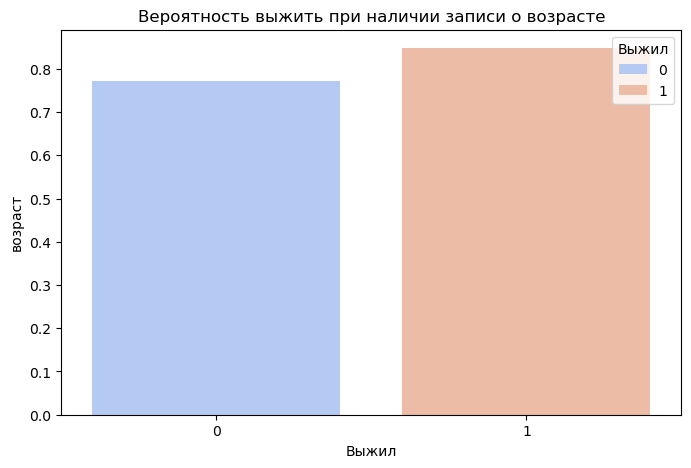

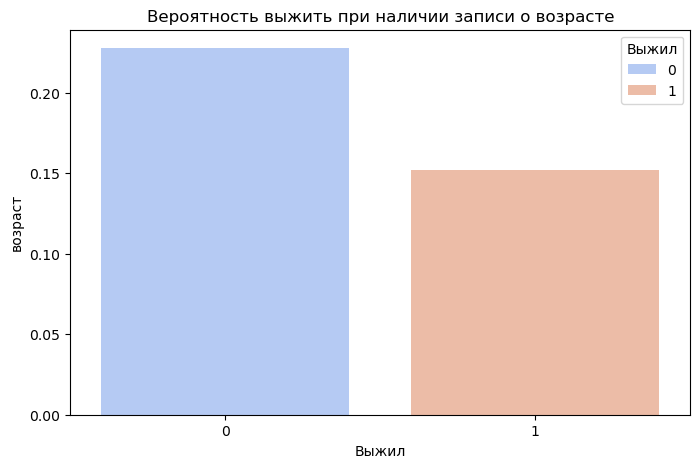

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x=df['Выжил'], y=df['возраст'].notnull(), hue='Выжил', errorbar=None, palette='coolwarm')
plt.title('Вероятность выжить при наличии записи о возрасте')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x=df['Выжил'], y=df['возраст'].isnull(), hue='Выжил', errorbar=None, palette='coolwarm')
plt.title('Вероятность выжить при наличии записи о возрасте')
plt.show()

### разница несущественная, но всеравно создаем новый признак для будующих экспериментов (возможно модель будет немного лучше)

In [7]:
df['без_возраста'] = df['возраст'].isnull().astype(int)


### удаление бесполезных столбцов

In [8]:
df=df.drop(['id_пассажира','имя','Билет','Каюта'], axis = 1)


### кодируем пол чтобы проверить корреляции + создаем дф из числовых для работы с matplotlib

In [9]:
df['пол'] = df['пол'].map({'male': 0, 'female': 1})

df_Plot = df.select_dtypes(include='number')
df['пол']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: пол, Length: 891, dtype: int64

### смотрим корреляции с столбцом 'Выжил'

In [10]:
correls = df_Plot.corr()['Выжил'].abs().sort_values(ascending=False)
correls

Выжил                          1.000000
пол                            0.543351
класс                          0.338481
каюта_отсутствует              0.316912
цена                           0.257307
без_возраста                   0.092197
родители_и_дети                0.081629
возраст                        0.077221
количество_братьев_супругов    0.035322
Name: Выжил, dtype: float64

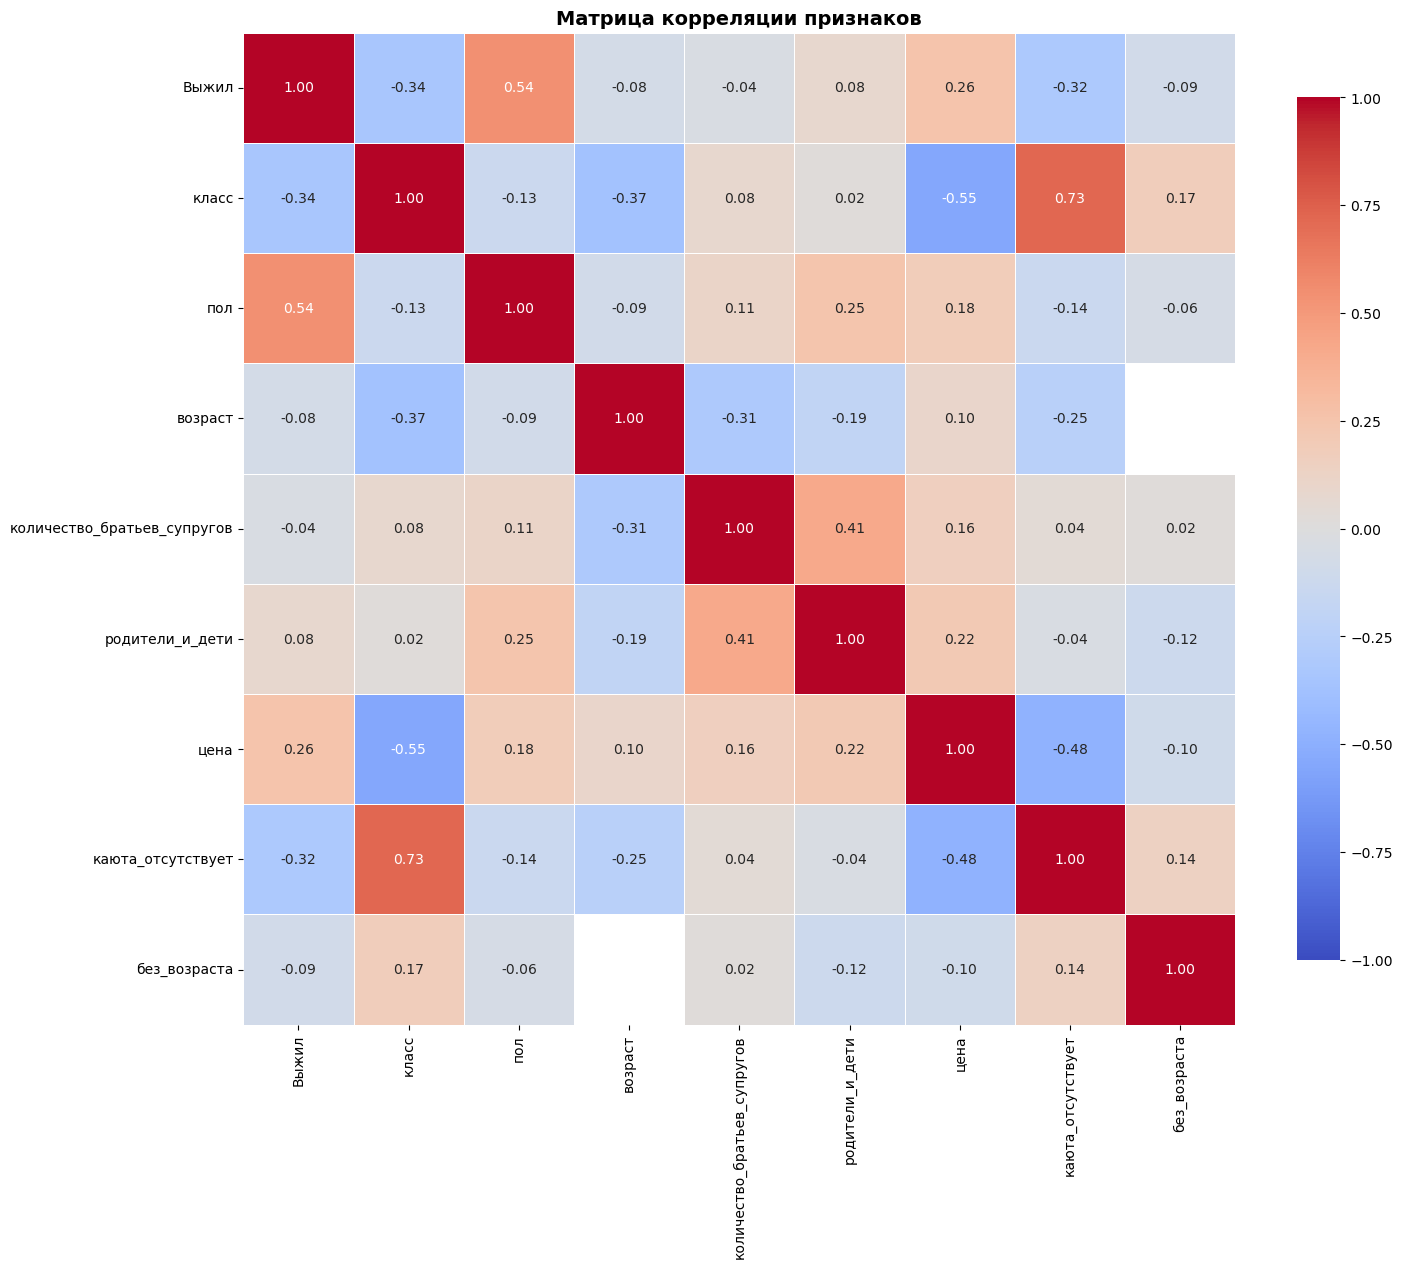

In [11]:

correl = df_Plot.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(correl, 
            annot=True,           # показывать числа
            cmap='coolwarm',      # цветовая схема (красный = 1, синий = -1)
            center=0,             # центр палитры (0 = белый)
            vmin=-1, vmax=1,      # диапазон значений
            square=True,          # квадратные клетки
            fmt='.2f',            # два знака после запятой
            linewidths=0.5,       # тонкие линии между клетками
            cbar_kws={'shrink': 0.8})  # размер цветовой шкалы
plt.title('Матрица корреляции признаков', fontsize=14, fontweight='bold')
plt.show()

## выводы по матрице:
#### 1) 'класс' и 'каюта_отсутствует' сильно коррелируют. значит что у первого класса часто знали каюту, а у низких классов нет. при этом 'выжил' коррелирует с классом. отсюда можно сделать вывод, что ,возможно, 'каюта_отсутствует' коррелирует с выживаемостью из за класса
#### 2) возраст коррелирует с классом (похоже богатенькие были постарше)
#### 3) похоже 'каюта_отсутствует' и 'цена' коррелируют тоже из за класса
#### 4) дамы слишком хорошо выживали


## работа с возрастом и портом


In [12]:

df['порт'] = df['порт'].fillna('S')# замена пропусков на S (самый частый порт)

#print(df.groupby(['класс', 'пол'])['возраст'].mean()) # средний возраст по классам и полу

            ### группируем по самым логичным признакам: класс (первый класс был старше) и пол (женщины в среднем были моложе)

df['возраст'] = df.groupby(['класс', 'пол'])['возраст'].transform(
    lambda x: x.fillna(x.median()))


            ### группируем по самым коррелирующим признакам: класс и количество_братьев_супругов (модель стала хуже, оставляем то что выше)

# df['возраст'] = df.groupby(['класс', 'количество_братьев_супругов'])['возраст'].transform(
#     lambda x: x.fillna(x.median()))

#             ### дозаполняем 7 пропусков на которые не создались группы (большие семьи которых мало)

# df['возраст'] = df.groupby(['класс', 'пол'])['возраст'].transform(
#     lambda x: x.fillna(x.median()))



### создаем 3 столбца из трех портов (для линейной модели). не кодируем все в одной колонке, чтобы модель не подумала, что порт 2 больше чем порт 1


In [13]:

port_dummies = pd.get_dummies(df['порт'], prefix='порт').astype(int)
df = pd.concat([df, port_dummies], axis=1)

df = df.drop('порт', axis=1)


## создание общей колонки "семья"

In [14]:

df["семья"] = (df['количество_братьев_супругов']+df['родители_и_дети']+1)


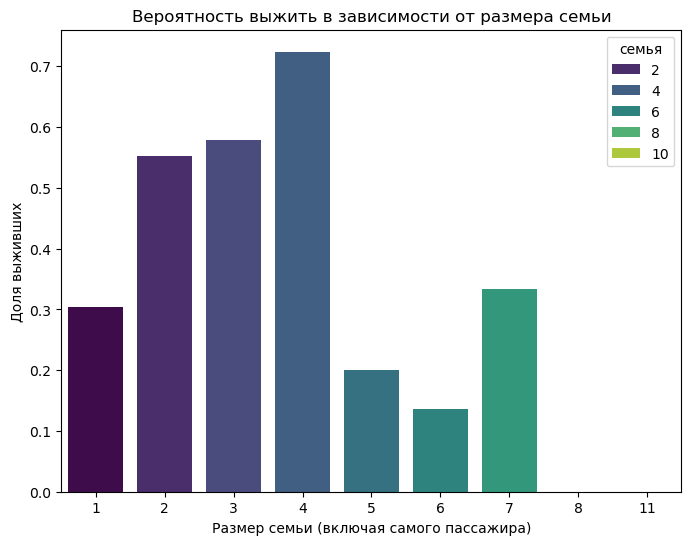

In [15]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='семья', y='Выжил', errorbar=None, hue =  'семья', palette='viridis')
plt.title('Вероятность выжить в зависимости от размера семьи')
plt.xlabel('Размер семьи (включая самого пассажира)')
plt.ylabel('Доля выживших')
plt.show()


## разбираемся откуда выброс у семьи из 7 чел.

In [16]:
len(df[df['семья']==7])# вывод "12" - значит на борту всего 2 семьи по 7 человек (причина выброса маленькая выборка+случайность)

            ### парадокс - в семье из 11 человек 7 строк, в семье из 8 человек 6 строк, а у 2 семьи по 7 человек 12 вместо 14 (похоже данные не полные или неверные)
# gross_family = df[df['семья']>7]
# gross_family

12

### т.к. распределение семьи и выживаемости не линейное, то для линейной модели разбиваем на группы семью

In [17]:
# Разбиваем семью на группы
df['семья_группа'] = pd.cut(df['семья'], 
                            bins=[0, 1, 4, 10], 
                            labels=['один', 'малая_семья', 'большая_семья'])

family_dummies = pd.get_dummies(df['семья_группа'], prefix='семья')*1
df = pd.concat([df, family_dummies], axis=1)
df = df.drop(['семья_группа'], axis = 1)
df

,Выжил,класс,пол,возраст,количество_братьев_супругов,родители_и_дети,цена,каюта_отсутствует,без_возраста,порт_C,порт_Q,порт_S,семья,семья_один,семья_малая_семья,семья_большая_семья
0,0,3,0,22.0,1,0,7.2500,1,0,0,0,1,2,0,1,0
1,1,1,1,38.0,1,0,71.2833,0,0,1,0,0,2,0,1,0
2,1,3,1,26.0,0,0,7.9250,1,0,0,0,1,1,1,0,0
3,1,1,1,35.0,1,0,53.1000,0,0,0,0,1,2,0,1,0
4,0,3,0,35.0,0,0,8.0500,1,0,0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,1,0,0,0,1,1,1,0,0
887,1,1,1,19.0,0,0,30.0000,0,0,0,0,1,1,1,0,0
888,0,3,1,21.5,1,2,23.4500,1,1,0,0,1,4,0,1,0
889,1,1,0,26.0,0,0,30.0000,0,0,1,0,0,1,1,0,0


# переходим к модели

### библиотеки

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier


## определяем признаки и целевую переменную для обучения модели

In [19]:
drops_colls = ['Выжил', 'каюта_отсутствует']#, 'без_возраста'] 
df_feature = df.drop(drops_colls,axis = 1)
feature = df_feature.columns
X = df_feature
y = df['Выжил']

# разделяем
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# масштабируем
numeric = ['возраст', 'цена', 'семья']#, 'класс']
scaler = StandardScaler()
X_train[numeric] = scaler.fit_transform(X_train[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])

# обучаем
model = LogisticRegression(max_iter=1000) 
model.fit(X_train, y_train) 

# точность
y_pred = model.predict(X_test) 
print(f"Точность: {accuracy_score(y_test, y_pred):.2%}")

# признаки по важности
coef = np.abs(model.coef_[0])
coef_df = pd.DataFrame({'признак': feature, 'коэффициент': coef}).sort_values('коэффициент', ascending=False)
print(coef_df)

Точность: 81.72%
                        признак  коэффициент
1                           пол     2.387051
0                         класс     0.887708
12            семья_малая_семья     0.794778
13          семья_большая_семья     0.728181
6                  без_возраста     0.482619
2                       возраст     0.455056
11                   семья_один     0.454030
9                        порт_S     0.351529
8                        порт_Q     0.209725
7                        порт_C     0.159406
3   количество_братьев_супругов     0.158122
5                          цена     0.133051
4               родители_и_дети     0.066029
10                        семья     0.063039


### пробуем кроссвалидацию на КНН

In [20]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Модель 1 (без признака)
X1 = df[['класс', 'пол', 'возраст', 'цена', 'порт_C', 'порт_Q', 'порт_S', 'семья']]
pipeline1 = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
scores1 = cross_val_score(pipeline1, X1, y, cv=cv, scoring='accuracy')

# Модель 2 (с признаком)
X2 = df[['класс', 'пол', 'возраст', 'цена', 'порт_C', 'порт_Q', 'порт_S', 'семья', 'семья_малая_семья','семья_большая_семья', 'каюта_отсутствует']]
pipeline2 = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
scores2 = cross_val_score(pipeline2, X2, y, cv=cv, scoring='accuracy')

print(f"Без признака: {scores1.mean():.2%} ± {scores1.std():.2%}")
print(f"С признаком:  {scores2.mean():.2%} ± {scores2.std():.2%}")



Без признака: 81.48% ± 0.71%
С признаком:  80.80% ± 2.64%


### подобраны признаки Х2 которые дают самый высокий результат

### тоже самое на логистической регрессии

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Модель 1 (без признака)
X1 = df[['класс', 'пол', 'возраст', 'цена', 'порт_C', 'порт_Q', 'порт_S', 'семья']]
pipeline1 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
scores1 = cross_val_score(pipeline1, X1, y, cv=cv, scoring='accuracy')

# Модель 2 (с признаком)
X2 = df[['класс', 'пол', 'возраст', 'цена', 'порт_C', 'порт_Q', 'порт_S', 'семья', 'семья_малая_семья','семья_большая_семья', 'каюта_отсутствует', 'семья_один', 'без_возраста', 'количество_братьев_супругов']]
pipeline2 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
scores2 = cross_val_score(pipeline2, X2, y, cv=cv, scoring='accuracy')

print(f"Без признака: {scores1.mean():.2%} ± {scores1.std():.2%}")
print(f"С признаком:  {scores2.mean():.2%} ± {scores2.std():.2%}")

Без признака: 79.80% ± 1.07%
С признаком:  81.37% ± 2.16%
